In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats.distributions import norm
import scipy.stats as stats

data = np.genfromtxt('data/data_yerr.dat', names=True, comments='#', delimiter='&')
data

array([( 1., 201., 592., 61.), ( 2., 244., 401., 25.),
       ( 3.,  47., 583., 38.), ( 4., 287., 402., 15.),
       ( 5., 203., 495., 21.), ( 6.,  58., 173., 15.),
       ( 7., 210., 479., 27.), ( 8., 202., 504., 14.),
       ( 9., 198., 510., 30.), (10., 158., 416., 16.),
       (11., 165., 393., 14.), (12., 201., 442., 25.),
       (13., 157., 317., 52.), (14., 131., 311., 16.),
       (15., 166., 400., 34.), (16., 160., 337., 31.),
       (17., 186., 423., 42.), (18., 125., 334., 26.),
       (19., 218., 533., 16.), (20., 146., 344., 22.)],
      dtype=[('index', '<f8'), ('x', '<f8'), ('y', '<f8'), ('sigm_y', '<f8')])

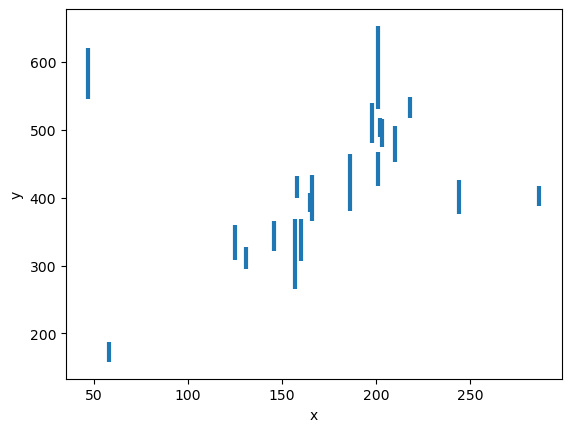

In [52]:
plt.errorbar(data['x'], data['y'], yerr=data['sigm_y'], linewidth=0, elinewidth=3)
plt.xlabel('x')
plt.ylabel('y')

xlim = plt.xlim()

plt.show()

In [54]:
xlim

(np.float64(35.0), np.float64(299.0))

<font color='orange'> Homework
    
    This time, we are going to build something to find where the peak is. 
    
    1. Assume uniform prior over slope and y-intercept. 

    2. Use Metropolis algorithm to draw samples from the posterior density function describing our knowledge of the slope and y-intercept given the observed data.
   
        - extend 1D MCMC to 2D
    
        - show quality of fit and associated uncertainty

    3. Make figure(s) showing estimate of the 2D posterior distribution.
    
        - are there correlations? </font>

#### <font color='orange'> Metropolis Algorithm </font>

The prior $q(x)$ is uniform: $q(x) \sim \mathcal{U}(x)$



In [4]:
def build_model(m,b):
    def model(x):
        return m * x + b
    return model

def lnlikelihood(m, b, x=data['x'], y=data['y'], sigma_y=data['sigm_y']):
    model = build_model(m, b)
    lnlike = -.5*np.sum(np.log(2*np.pi*sigma_y**2)) - np.sum((y - model(x))**2/(2*sigma_y**2)) # coded up log liklihood
    return lnlike

I want to have MCMC constrain values for both slope *and* y-intercept making this a 2D MCMC which implies two chains.

In [5]:
# starting values picked from the Intro to Linear Regression Notebook 
# from this notebook we already know that the optimal values for m and b are 1.08 and 213.27
m0 = 1.
b0 = 200.

m = m0
b = b0
p_current = lnlikelihood(m, b)
# define chains
m_chain = [m]
b_chain = [b]

# the chains are linked so so is the probability
probs = [p_current]

Now to implement the Metropolis algorithm expanded to be 2D...

In [6]:
niter = 50000
sigma_m = 0.05
sigma_b = 5.0

for i in range(niter):
    mp = norm.rvs(loc=m, scale=sigma_m)
    bp = norm.rvs(loc=b, scale=sigma_b)
    p_p = lnlikelihood(mp, bp)
   # print(p_p)
    
    alpha = p_p - p_current
    u = np.random.uniform()
    accepted = u < np.exp(alpha)
   # print(alpha)

    
    if accepted:
        m = mp
        b = bp
        p_current = p_p
    m_chain.append(m)
    b_chain.append(b)
    probs.append(p_current)

# print("Acceptance rate:", n_accept / niter)

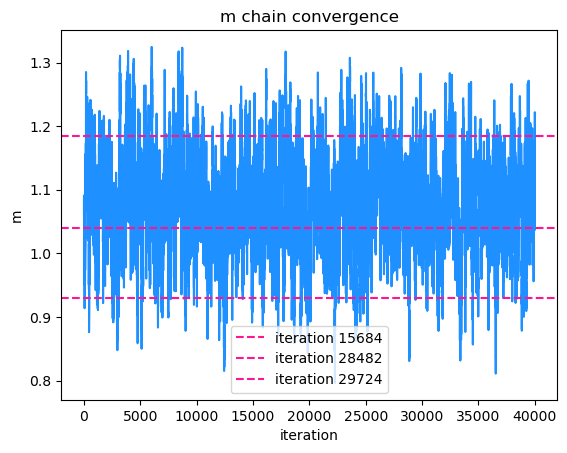

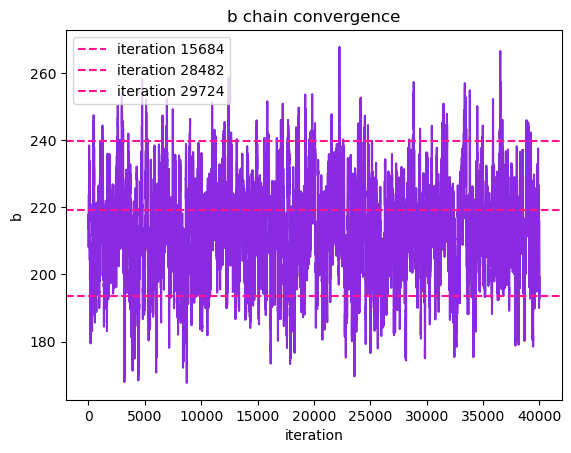

In [59]:
# burnin < niter
burnin = 10000
n = np.random.randint(burnin, len(b_chain), size=3)

plt.plot(m_chain[burnin:], color='dodgerblue')
for idx in n:
    plt.axhline(m_chain[idx], color='deeppink', linestyle='--', label=f'iteration {idx}')
plt.xlabel('iteration')
plt.ylabel('m')
plt.title('m chain convergence')
plt.legend()
plt.show()

plt.plot(b_chain[burnin:], color='blueviolet')
for idx in n:
    plt.axhline(b_chain[idx], color='deeppink', linestyle='--', label=f'iteration {idx}')
plt.xlabel('iteration')
plt.title('b chain convergence')
plt.ylabel('b')
plt.legend()
plt.show()

yay fuzzy caterpillar!

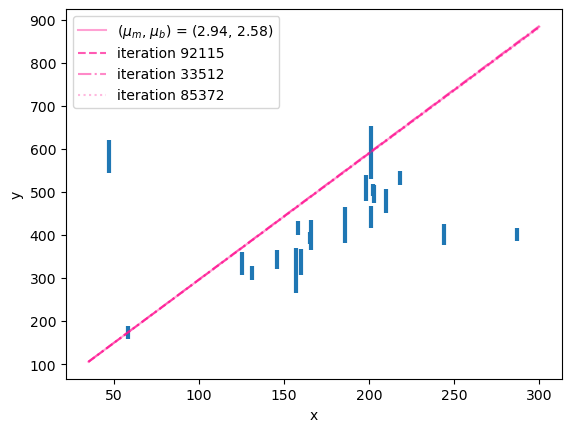

In [83]:
# plotting the chains on the data
m_samples = np.array(chain_m[burnin_length:])
b_samples = np.array(chain_b[burnin_length:])
mean_m = np.mean(m_samples)
med_m = np.median(m_samples)
std_m = np.std(m_samples)
mean_b = np.mean(b_samples)
med_b = np.median(b_samples)
std_b = np.std(b_samples)

test_x = np.linspace(35, 300, 20)

plt.errorbar(data['x'], data['y'], yerr=data['sigm_y'], linewidth=0, elinewidth=3)
plt.xlabel('x')
plt.ylabel('y')

# from itertools import cycle
# markers = cycle(['.', 'd', 'X'])
# for idx in n:
#     model = build_model(m_samples[idx], b_samples[idx])
#     plt.plot(test_x, model(test_x), alpha=0.3, color='deeppink', marker=next(markers), label=f'Sample {i+1}')
model_1 = build_model(m_samples[n[0]],b_samples[n[0]])
model_2 = build_model(m_samples[n[1]],b_samples[n[1]])
model_3 = build_model(m_samples[n[2]],b_samples[n[2]])
best_fit_model = build_model(mean_m, mean_b)

plt.plot(test_x, best_fit_model(test_x), alpha= 0.4, color='deeppink', label=fr'($\mu_m$, $\mu_b$) = (${round(mean_m,2)}$, ${round(mean_b,2)}$)')
plt.plot(test_x, model_1(test_x), color='deeppink', linestyle='--', alpha=0.7, label=f'iteration {n[0]}')
plt.plot(test_x, model_2(test_x), color='deeppink', linestyle='-.', alpha=0.5, label=f'iteration {n[1]}')
plt.plot(test_x, model_3(test_x), color='deeppink', linestyle=':', alpha=0.3, label=f'iteration {n[2]}')


plt.legend()
plt.show()

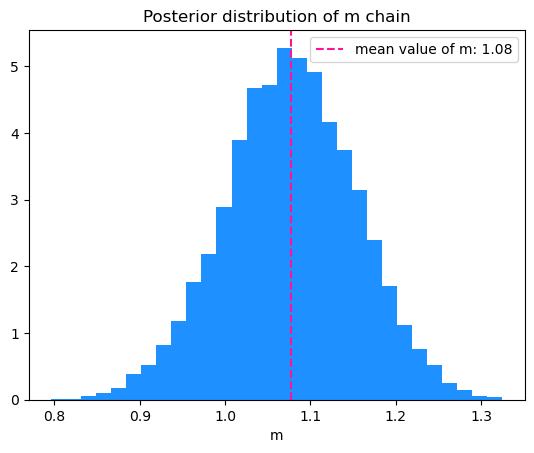

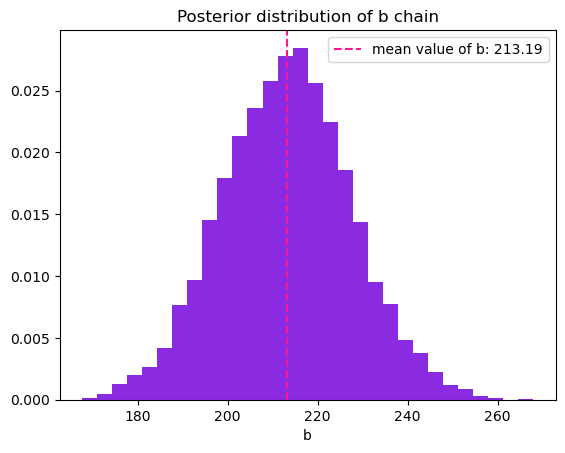

In [8]:
# plotting the distribution

plt.hist(m_chain[burnin:], color='dodgerblue',density=True, bins=30)
plt.xlabel('m')
plt.axvline(np.mean(m_chain[burnin:]), linestyle='--', color='deeppink', label=f'mean value of m: {np.mean(m_chain[burnin:]):.2f}')
plt.legend()
plt.title('Posterior distribution of m chain')
plt.show()

plt.hist(b_chain[burnin:], density=True, color='blueviolet', bins=30)
plt.axvline(np.mean(b_chain[burnin:]), linestyle='--', color='deeppink', label=f'mean value of b: {np.mean(b_chain[burnin:]):.2f}')
plt.legend()
plt.xlabel('b')
plt.title('Posterior distribution of b chain')
plt.show()

With mean values of b = 213.63 and m = 1.08, these are near spot on with the linear regression! (b = 213.27, m = 1.08).

## Grad student part

#### 1. Select only the stars from the data set with parallax > 40 mas.

In [9]:
# first, step zero here, lets import the data

df = pd.read_csv('../../../../hub_data_share/gaiadr3_solar_neighborhood.csv')

# select only stars with parallax over 40
nearby_sel = df.parallax > 40
nearby_df = df[nearby_sel]

nearby_df

,mg,bp_rp,parallax
223559,11.544313,2.992254,40.002314
223560,13.563787,3.794676,40.004848
223561,10.197586,2.492932,40.007115
223562,12.769197,3.373776,40.014745
223563,12.413716,3.135756,40.019696
...,...,...,...
227624,11.758283,2.834036,336.026602
227625,9.521769,2.215609,392.752945
227626,14.129570,4.184836,415.179416
227627,11.883816,2.833697,546.975940


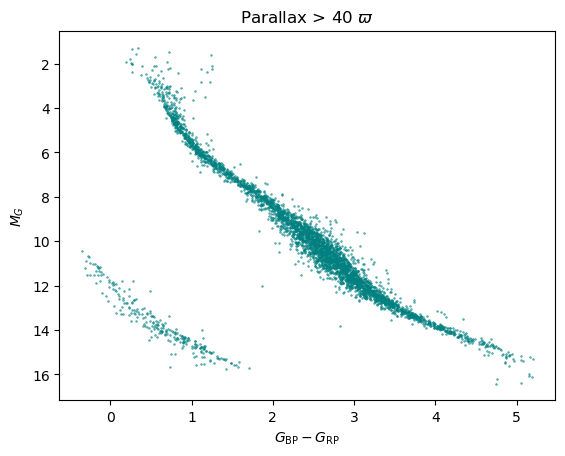

In [41]:
plt.scatter(nearby_df.bp_rp, nearby_df.mg, color='teal', marker='*', s=1, alpha=0.5)
plt.gca().invert_yaxis()
plt.xlabel(r'$G_\mathrm{BP} - G_\mathrm{RP}$')
plt.ylabel(r'$M_G$')
plt.title(r'Parallax > 40 $\varpi$')
plt.show()

#### 2. (crudely) remove the white dwarfs (constructing a dividing line by eye is fine for this).

In [11]:
print(min(nearby_df.bp_rp), max(nearby_df.mg))

-0.34853935 16.40824032082896


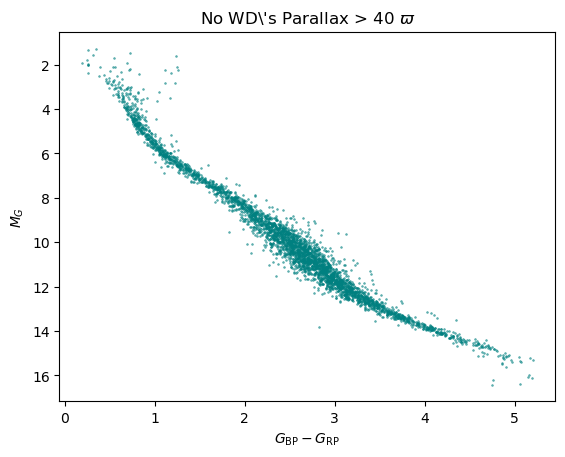

In [88]:
wd_color = (-0.4, 2)
wd_mg = (10, 16.5)

wd_sel = ((nearby_df.bp_rp > wd_color[0]) & (nearby_df.bp_rp < wd_color[1]) & (nearby_df.mg > wd_mg[0]) & (nearby_df.mg < wd_mg[1]))

nearby_nowd_df = nearby_df[~wd_sel]

plt.scatter(nearby_nowd_df.bp_rp, nearby_nowd_df.mg ,color='teal', marker='*', s=1, alpha=0.5)
plt.gca().invert_yaxis()
plt.xlabel(r'$G_\mathrm{BP} - G_\mathrm{RP}$')
plt.ylabel(r'$M_G$')
plt.title(r'No WD\'s Parallax > 40 $\varpi$')

xlim = plt.xlim()
plt.show()

#### 3. Define your likelihood.  
This will be similar to the last linear regression likelihood, except that we don't have uncertainties on measurements of the brightness, Mg.  Even if we did, the scatter about the linear relationship is due to physics not measurement uncertainty, so we'll need to infer it from the data.

In [35]:
# sigma = np.std(nearby_wd_df)
# sigma

def lnlike_gaia(m, b, sigma_y, x=nearby_nowd_df['bp_rp'], y=nearby_nowd_df['mg']):
    model = build_model(m, b)
    N = len(y)
    lnlike = -.5*N*np.sum(np.log(2*np.pi*sigma_y**2)) - np.sum((y - model(x))**2/(2*sigma_y**2)) # coded up log liklihood
    return lnlike

#### 4. Define priors.  
Uniform priors on slope and y-intercept are fine, but you'll need to impose a prior on the scatter in $M_G$ about the line, $\sigma_{M_G}$, that ensures it stays positive and doesn't run away.  I suggest a normal distribution with $\sigma \sim 5$ for $\sigma_{M_G} > 0$.

In [36]:
x = nearby_nowd_df['bp_rp']
y = nearby_nowd_df['mg']
m0 = 4.0
b0 = -1.0

sigma_mg_prior = stats.halfnorm.rvs(loc=10,scale=5)
# plt.hist(sigma_mg_prior, bins=30, density=True)
# plt.title(r'$\sigma_{MG}$ prior')
# plt.show()

#### 5. Perform your first 3-D MCMC.

In [37]:
# 3D --> 3 chains w/ w itl cdts
m = m0
b = b0
sigma_mg = sigma_mg_prior
p_current = lnlike_gaia(m, b, sigma_mg)

chain_m = [m]
chain_b = [b]
chain_sigma = [sigma_mg]
probs = [p_current]

In [38]:
# Implement 3D Metropolis Algorithm
niter = 100000
sigma_jump_m = 0.1
sigma_jump_b = 0.1
sigma_jump_sigma_mg = 0.1 #placeholder values

for i in range(niter):
    mp = norm.rvs(loc=m, scale=sigma_jump_m)
    bp = norm.rvs(loc=b, scale=sigma_jump_b)
    sigma_mg_p = norm.rvs(loc=sigma_mg, scale=sigma_jump_sigma_mg)
    p_pm = lnlike_gaia(mp, b, sigma_mg)
    p_pb = lnlike_gaia(m, bp, sigma_mg)
    p_ps = lnlike_gaia(m, b, sigma_mg_p)
    
    alpha_m = p_pm - p_current
    alpha_b = p_pb - p_current
    alpha_sigma = p_ps - p_current
    u = np.random.uniform()

    if alpha_m >= 0:
        accepted_m = True
    else:
        accepted_m = np.log(u) < alpha_m
    if alpha_b >= 0:
        accepted_b = True
    else:
        accepted_b = np.log(u) < alpha_b
    if alpha_sigma >= 0:
        accepted_sigma = True
    else:
        accepted_sigma = np.log(u) < alpha_sigma

    
    if accepted_m:
        m = mp
    if accepted_b:
        b = bp
    if accepted_sigma:
        sigma_mg = sigma_mg_p
    
    p_current = lnlike_gaia(m, b, sigma_mg)
    
    chain_m.append(m)
    chain_b.append(b)
    chain_sigma.append(sigma_mg)
    probs.append(p_current)

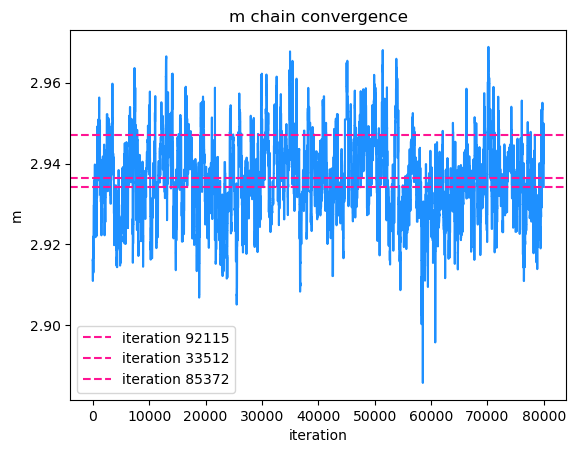

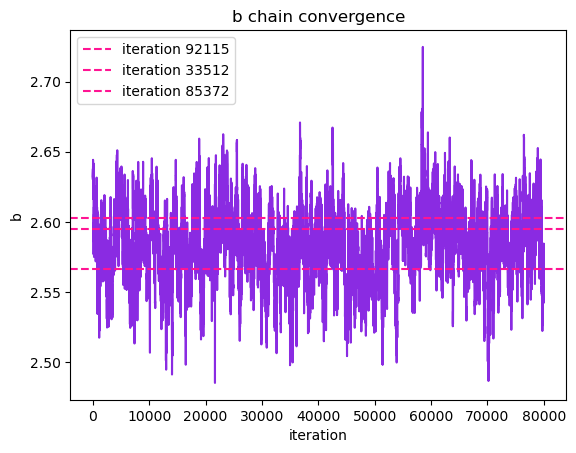

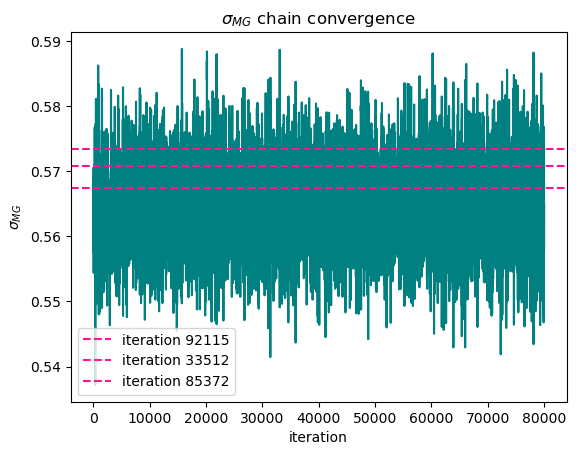

In [80]:
# plot fuzzy caterpillars (hopefully)
# burnin < niter

########### B Caterpillar #############
burnin = 2 * 10**4
n = np.random.randint(burnin, len(chain_m), size=3)

plt.plot(chain_m[burnin:], color='dodgerblue')
for idx in n:
    plt.axhline(chain_m[idx], color='deeppink', linestyle='--', label=f'iteration {idx}')
plt.legend()
plt.xlabel('iteration')
plt.ylabel('m')
plt.title('m chain convergence')
plt.show()

############ M Caterpillar #################

plt.plot(chain_b[burnin:], color='blueviolet')
for idx in n:
    plt.axhline(chain_b[idx], color='deeppink', linestyle='--', label=f'iteration {idx}')
plt.legend()
plt.xlabel('iteration')
plt.title('b chain convergence')
plt.ylabel('b')
plt.show()

########## SIGMA_MG Caterpillar ###################

plt.plot(chain_sigma[burnin:], color='teal')
for idx in n:
    plt.axhline(chain_sigma[idx], color='deeppink', linestyle='--', label=f'iteration {idx}')
plt.legend()
plt.xlabel('iteration')
plt.title(r'$\sigma_{MG}$ chain convergence')
plt.ylabel(r'$\sigma_{MG}$')
plt.show()

mean m: 2.9374889049356905 
mean b: 2.579569557951842 
mean sigma: 0.5898388486905104


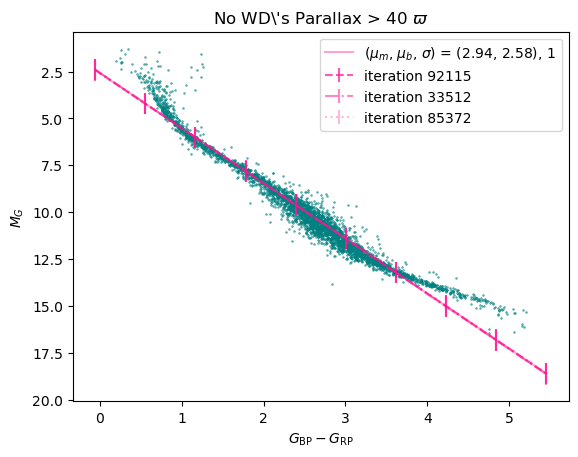

In [93]:
# plot
####### THE DATA ###########
plt.scatter(nearby_nowd_df.bp_rp, nearby_nowd_df.mg ,color='teal', marker='*', s=1, alpha=0.5)
###########################

######### MODEL MAKING ############
mean_m = np.mean(m_samples)
mean_b = np.mean(b_samples)
mean_sigma = np.mean(sigma_mg_samples)

print(f'mean m: {mean_m} \nmean b: {mean_b} \nmean sigma: {mean_sigma}')

model_1 = build_model(m_samples[n[0]],b_samples[n[0]])
model_2 = build_model(m_samples[n[1]],b_samples[n[1]])
model_3 = build_model(m_samples[n[2]],b_samples[n[2]])
best_fit_model = build_model(mean_m, mean_b)

xlow, xhigh = xlim
test_x = np.linspace(xlow, xhigh, 10)

########### MODEL PLOTTING #############
plt.errorbar(test_x, best_fit_model(test_x), alpha= 0.4, color='deeppink', label=fr'($\mu_m$, $\mu_b$, $\sigma$) = (${round(mean_m,2)}$, ${round(mean_b,2)}$), ${round(mean_sigma)}$')
plt.errorbar(test_x, model_1(test_x), yerr=sigma_mg_samples[n[0]], color='deeppink', linestyle='--', alpha=0.7, label=f'iteration {n[0]}')
plt.errorbar(test_x, model_2(test_x), yerr=sigma_mg_samples[n[1]], color='deeppink', linestyle='-.', alpha=0.5, label=f'iteration {n[1]}')
plt.errorbar(test_x, model_3(test_x), yerr=sigma_mg_samples[n[2]], color='deeppink', linestyle=':', alpha=0.3, label=f'iteration {n[2]}')


plt.gca().invert_yaxis()
plt.xlabel(r'$G_\mathrm{BP} - G_\mathrm{RP}$')
plt.ylabel(r'$M_G$')
plt.title(r'No WD\'s Parallax > 40 $\varpi$')
plt.legend()
plt.show()

##### Are there correlations between the constraints on the model parameters?

We can check the covariance matrix!

$$\sigma_{jk} = \sqrt{[F^{-1}]_{jk}}, $$

where

$$ F_{jk} = - \frac{\partial^2}{\partial\theta_j} \frac{\ln L}{\partial\theta_k} \Biggr\rvert_{\theta=\hat \theta}$$

In [46]:
m_samples = np.array(chain_m[burnin_length:])
b_samples = np.array(chain_b[burnin_length:])
sigma_mg_samples = np.array(chain_sigma[burnin_length:])

corr_mb = np.corrcoef(m_samples, b_samples)
corr_ms = np.corrcoef(m_samples, sigma_mg_samples)
corr_bs = np.corrcoef(b_samples, sigma_mg_samples)
print(f'correlation matrix between m and b:\n{corr_mb}')
print(f'correlation matrix between m and sigma_mg:\n{corr_ms}')
print(f'correlation matrix between b and sigma_mg:\n{corr_bs}')

correlation matrix between m and b:
[[ 1.         -0.98647135]
 [-0.98647135  1.        ]]
correlation matrix between m and sigma_mg:
[[1.         0.88119888]
 [0.88119888 1.        ]]
correlation matrix between b and sigma_mg:
[[ 1.         -0.88789529]
 [-0.88789529  1.        ]]


There are correlations yipee

##### What did we infer regarding the scatter about the line, $\sigma_{M_G}$, and how does it compare to your by-eye assessment of the width of the scatter along the main sequence?